# Brain Tumor Detection


**Importing Libraries**

In [2]:
import os #for directory and file operation
import numpy as np
import random #help with generating random values for augmentation
import matplotlib.pyplot as plt #for plotting
from PIL import Image, ImageEnhance #help with image preprocessing

#keras library
from tensorflow.keras.models import Sequential #for layer by layer model
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense #inteconnected neurons
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle


**Connecting with Google Drive**

In [3]:
#linking google drive with colab
from google.colab import drive #linking google drive with colab
drive.mount('/content/drive')


Mounted at /content/drive


 **Loading Datasets**

In [4]:
train_dir = '/content/drive/MyDrive/ML AI with python Projects/Brain Tumor Detection/MRI images/Training'
test_dir= '/content/drive/MyDrive/ML AI with python Projects/Brain Tumor Detection/MRI images/Testing'

#load and shuffle train data
train_paths=[]
train_labels=[]

for label in os.listdir(train_dir):
  for image in os.listdir(os.path.join(train_dir,label)):
    train_paths.append(os.path.join(train_dir,label,image))
    train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

#load and shuffle test data
test_paths=[]
test_labels=[]

for label in os.listdir(test_dir):
  for image in os.listdir(os.path.join(test_dir,label)):
    test_paths.append(os.path.join(test_dir,label,image))
    test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)



**Data Visualization**

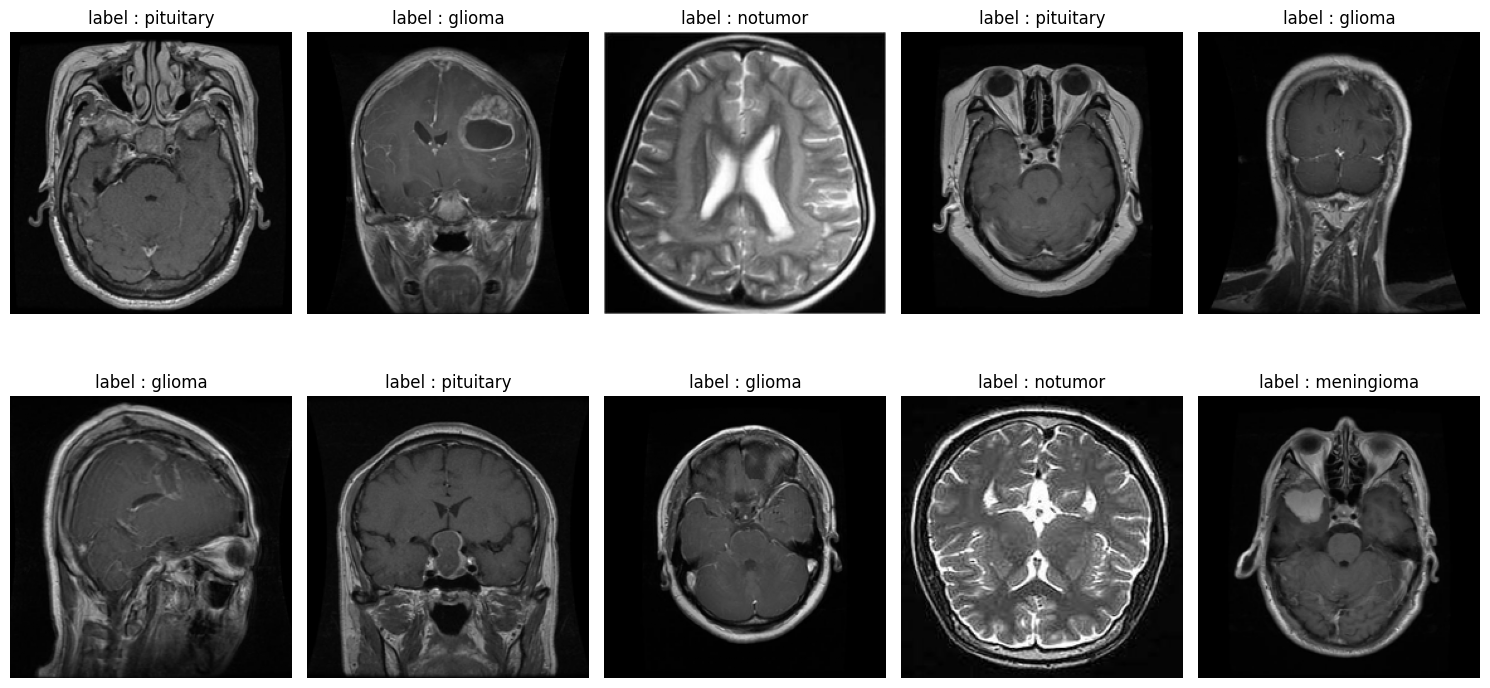

In [5]:
#select random indices for 10 images
random_indices = random.sample(range(len(train_paths)), 10)
random_indices

#creating figure to display images
fig, axes = plt.subplots(2, 5, figsize=(15, 8)) #2 rows, 5 columns , 15x8 each fig size
axes = axes.ravel()

#loop through random indices and display images
for i, index in enumerate(random_indices):
  img_path = train_paths[index]
  img = Image.open(img_path)
  img = img.resize((224,224))
  #display images
  axes[i].imshow(img,cmap='gray')
  axes[i].set_title(f"label : {train_labels[index]}")
  axes[i].axis('off')

plt.tight_layout()
plt.show()


**Image Preprocessing**

In [14]:
#Image Augmentation Function

def augment_image(image):
  image= np.uint8(image) #Converts the image into a standard format (0–255 numbers)
  image= Image.fromarray(image) #Converts image=> NumPy array → PIL image format (NumPy = raw numbers) (PIL = image object you can edit (brightness, contrast, etc.))
  #ImageEnhance.Brightness(image) → prepares brightness tool
  #random.uniform(0.8, 1.2) → picks a random number between:(0.8 → slightly darker, 1.0 → same brightness, 1.2 → slightly brighter)
  #every time you run it: Image might get darker Or brighter Randomly
  image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8,1.2))
  image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8,1.2))
  # will give pillow image so will do normalization
  image=np.array(image)/255.0
  return image

#Load images and apply augmentation on it function

def open_images(paths):
  images=[]
  for path in paths:
    image=load_img(path, target_size=(image_size,image_size))
    image=augment_image(image)
    images.append(image)
  return np.array(images)

#Encoding Labels Function (convert label names to integers)
#def encode_labels(labels):
 # unique_labels= os.listdir(train_dir)
  #encoded=[unique_labels.index(label) for label in labels]
  #return encoded

def encode_labels(labels):
    unique_labels = os.listdir(train_dir)  # Ensure unique labels are determined
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

#Data Generation Function (for batching)
def data_gen(paths,labels,batch_size=12,epochs=1):
  for _ in range(epochs):
    for i in range(0,len(paths),batch_size):
      batch_paths=paths[i:i+batch_size]
      batch_images=open_images(batch_paths)
      batch_labels=labels[i:i+batch_size]
      batch_labels=encode_labels(batch_labels)
      yield batch_images,batch_labels



**Model Architecture**

In [16]:
from IPython.core import history
# VGG16 pretrained model
# 128x128 with 3 color channels
# include_top= false (vgg16 has it's own classification layers but we want to use our own custom one )
# weight= imagenet (predefined weights on imagenet data bcz of its result)

image_size =128
base_model=VGG16(input_shape=(image_size,image_size,3) ,include_top=False,weights='imagenet')

#Freeze all layers of the VGG16 base model
for layer in base_model.layers:
  layer.trainable=False

#We need to unfreeze 2nd,3rd,4th last layers bcz it contain pretrained model knowledge
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

#Build model
model = Sequential()
model.add(Input(shape=(image_size,image_size,3))) #input layer of NN
model.add(base_model) #Add VGG16 for pretrained but output in 2d
model.add(Flatten()) #Flatten layer

model.add(Dropout(0.3)) #Dropout layer
model.add(Dense(128,activation='relu')) #Dense Layer (128 neurons)

model.add(Dropout(0.2)) #Dropout layer (20% neurons drop)
model.add(Dense(len(os.listdir(train_dir)),activation='softmax')) #Output layer (4 classes classification)

#Compile the model
#For multi classification we use sparse categorical cross entropy
model.compile(optimizer=Adam(learning_rate=0.0001),loss='sparse_categorical_crossentropy',metrics=['sparse_categorical_accuracy'])

#Model Training Parameters
batch_size=20
steps= int(len(train_paths)/batch_size)
epochs= 5

#Model Training
history = model.fit(
    data_gen(train_paths,train_labels,batch_size=batch_size,epochs=epochs),epochs=epochs,
    steps_per_epoch= steps
)

Epoch 1/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 1394s 5s/step - loss: 0.4776 - sparse_categorical_accuracy: 0.8139
Epoch 2/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 1395s 5s/step - loss: 0.2284 - sparse_categorical_accuracy: 0.9125
Epoch 3/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 1396s 5s/step - loss: 0.1555 - sparse_categorical_accuracy: 0.9404
Epoch 4/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 1386s 5s/step - loss: 0.1211 - sparse_categorical_accuracy: 0.9525
Epoch 5/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 1581s 6s/step - loss: 0.0894 - sparse_categorical_accuracy: 0.9679


**Train and Val Plot**

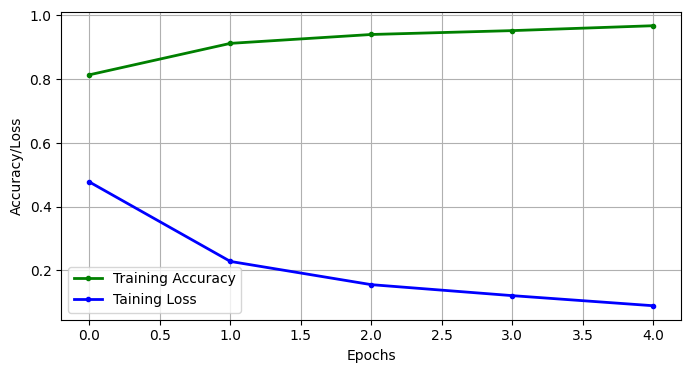

In [18]:
plt.figure(figsize=(8, 4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'],'.g-',linewidth=2, label='Training Accuracy')
plt.plot(history.history['loss'],'.b-',linewidth=2, label='Taining Loss')
plt.xlabel('Epochs')
plt.ylabel('Accuracy/Loss')
plt.legend()
plt.show()


**Model Classifiaction Report**

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize


test_images =open_images(test_paths)
test_labels_encoded = encode_labels(test_labels)

test_predictions = model.predict(test_images)
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

50/50 ━━━━━━━━━━━━━━━━━━━━ 394s 8s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       400
           1       0.85      0.93      0.89       400
           2       0.94      1.00      0.97       400
           3       0.95      0.78      0.86       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600



**Confusion Matrix**

Confusion Matrix:
[[395   4   0   1]
 [  9 370   5  16]
 [  0   1 399   0]
 [  8  60  20 312]]


<function matplotlib.pyplot.figure(num: 'int | str | Figure | SubFigure | None' = None, figsize: 'tuple[float, float] | None' = None, dpi: 'float | None' = None, *, facecolor: 'ColorType | None' = None, edgecolor: 'ColorType | None' = None, frameon: 'bool' = True, FigureClass: 'type[Figure]' = <class 'matplotlib.figure.Figure'>, clear: 'bool' = False, **kwargs) -> 'Figure'>

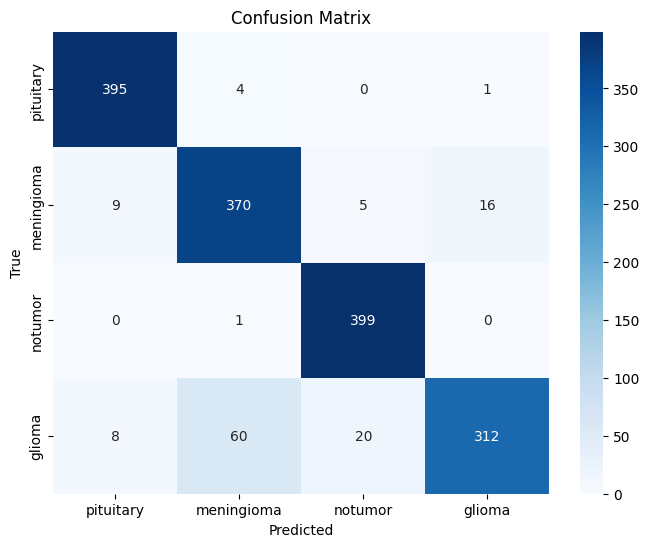

In [20]:
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.figure

**ROC Curve Plot**

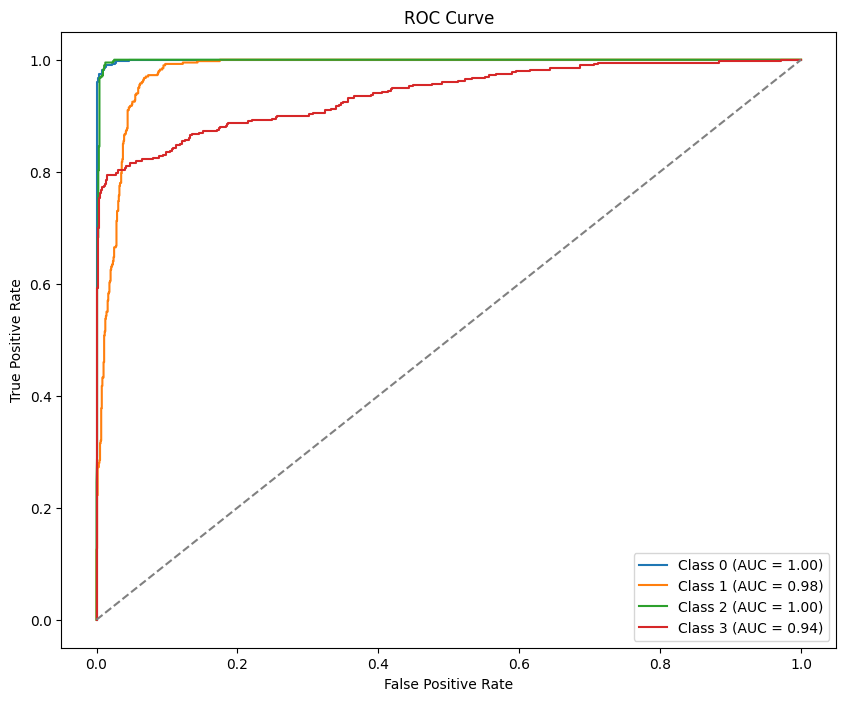

In [21]:
# 4. ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

**Save and Load Model**

In [22]:
model.save('/content/drive/MyDrive/ML AI with python Projects/Brain Tumor Detection/model.h5')

from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/ML AI with python Projects/Brain Tumor Detection/model.h5')

**MRI Tumor Detection System**

In [46]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np

class_labels = ['pituitary','meningioma','notumor','glioma']

def detect_and_display_tumor(image_path,model):
  try:
    #Load image
    img = load_img(image_path,target_size=(128,128))
    img_array = img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    #prediction
    prediction = model.predict(img_array)
    predicted_class_index = np.argmax(prediction)
    confidence_score = np.max(prediction , axis=1)[0]

    #Class Determination
    if class_labels[predicted_class_index] == 'notumor':
       result = "No Tumor"
    else:
       result = f"Tumor: {class_labels[predicted_class_index]}"

    # Display the image with the prediction
    plt.imshow(load_img(img_path))
    plt.axis('off')
    plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
    plt.show()
  except Exception as e:
    print("Error processing the image:", str(e))

**Example**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step


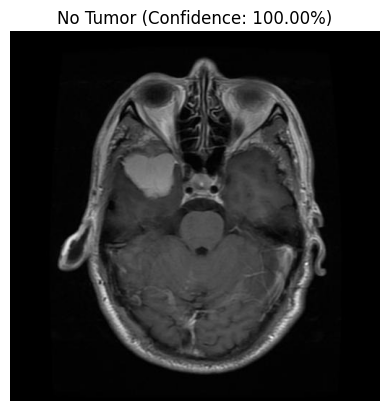

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step


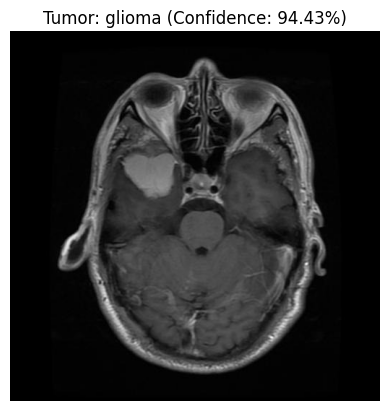

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 506ms/step


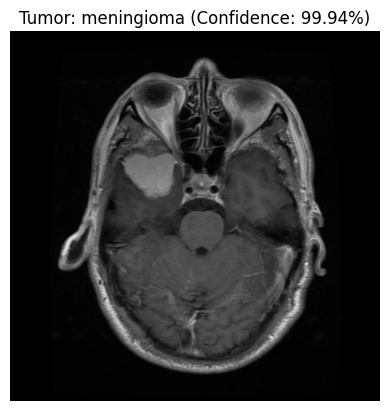

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step


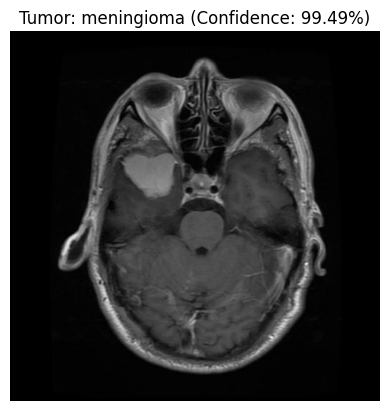

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step


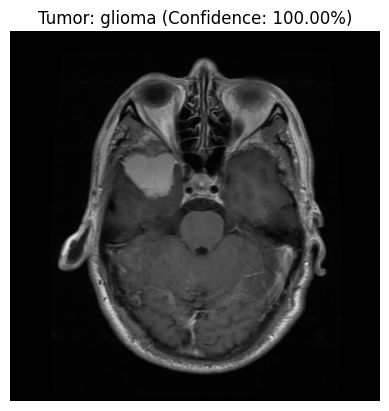

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step


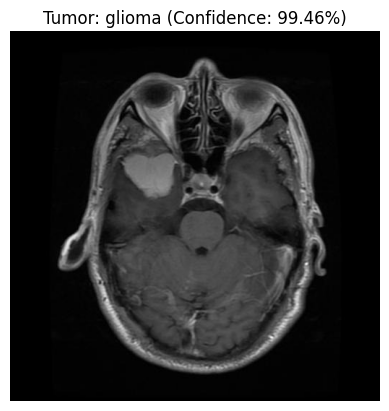

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step


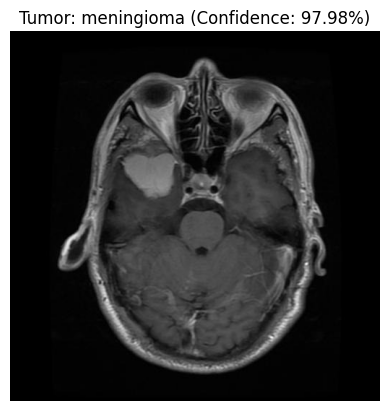

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step


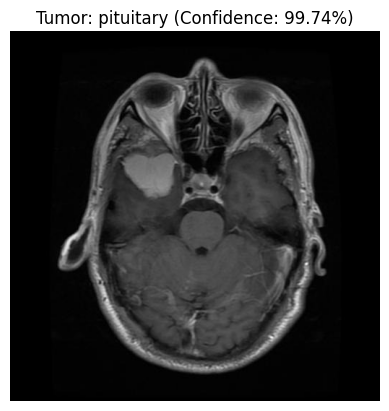

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step


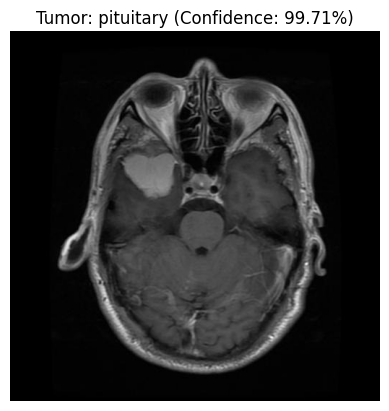

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step


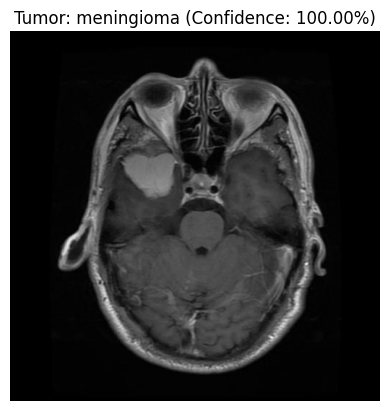

In [47]:
# Example usage
image_path = '/content/drive/MyDrive/ML AI with python Projects/Brain Tumor Detection/MRI images/Testing/notumor/Te-no_103.jpg'  # Provide the path to your new image
detect_and_display_tumor(image_path, model)

image_path = '/content/drive/MyDrive/ML AI with python Projects/Brain Tumor Detection/MRI images/Testing/glioma/Te-gl_202.jpg'  # Provide the path to your new image
detect_and_display_tumor(image_path, model)

image_path = '/content/drive/MyDrive/ML AI with python Projects/Brain Tumor Detection/MRI images/Testing/meningioma/Te-aug-me_12.jpg'  # Provide the path to your new image
detect_and_display_tumor(image_path, model)
image_path = '/content/drive/MyDrive/ML AI with python Projects/Brain Tumor Detection/MRI images/Testing/meningioma/Te-aug-me_10.jpg'  # Provide the path to your new image
detect_and_display_tumor(image_path, model)
image_path = '/content/drive/MyDrive/ML AI with python Projects/Brain Tumor Detection/MRI images/Testing/glioma/Te-gl_11.jpg'  # Provide the path to your new image
detect_and_display_tumor(image_path, model)

image_path = '/content/drive/MyDrive/ML AI with python Projects/Brain Tumor Detection/MRI images/Testing/glioma/Te-gl_119.jpg'  # Provide the path to your new image
detect_and_display_tumor(image_path, model)

image_path = '/content/drive/MyDrive/ML AI with python Projects/Brain Tumor Detection/MRI images/Testing/meningioma/Te-aug-me_11.jpg'  # Provide the path to your new image
detect_and_display_tumor(image_path, model)
image_path = '/content/drive/MyDrive/ML AI with python Projects/Brain Tumor Detection/MRI images/Testing/pituitary/Te-pi_11.jpg'  # Provide the path to your new image
detect_and_display_tumor(image_path, model)
image_path = '/content/drive/MyDrive/ML AI with python Projects/Brain Tumor Detection/MRI images/Testing/pituitary/Te-pi_98.jpg'  # Provide the path to your new image
detect_and_display_tumor(image_path, model)
image_path = '/content/drive/MyDrive/ML AI with python Projects/Brain Tumor Detection/MRI images/Testing/glioma/Te-gl_76.jpg'  # Provide the path to your new image
detect_and_display_tumor(image_path, model)